# Plotting the Cost Funciton for a Linear Model with two weights parameters

Below is a code for plotting the cost funciton of a linear model. The CostLinear function takes as input a grid of weights w0 and w1 and calculates the cost of each one of these settings for a model (y)
The code also plots the contour of the cost fucntion which shows how the cost increas when we move away from the ideal weights of w0=2, w1=3

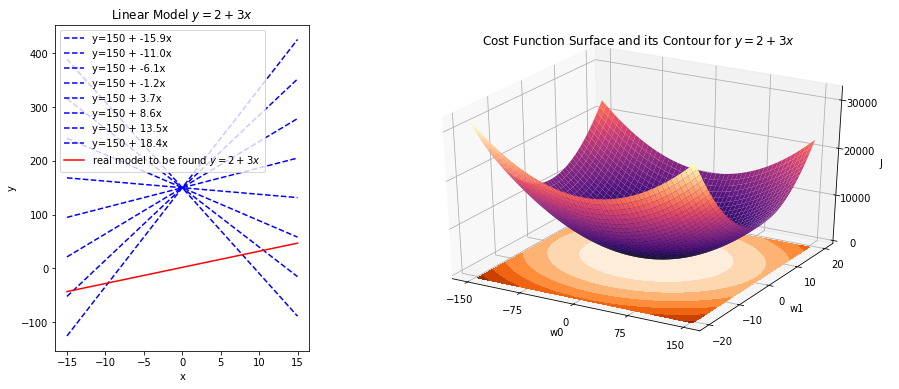

In [48]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.cm as cm
%matplotlib inline

def CostLinear(W0,W1,x,y,ax1):
    n0, n1 = len(W0), len(W1)
    J = np.zeros((n0,n1))
    J_points = np.zeros((n0,n1))
   
    # iterate through the meshgrid
    for i in range(n0):
        for j in range(n1):            
            ymdl = W0[i,j] + W1[i,j]*x             
            J[i,j] = np.sum((1/(2*n))*(y - ymdl)**2)
        if (i+j)%6==0: 
            ax1.plot(x,ymdl,'--b',label='y={} + {}x'.format(round(W0[i,j]), round(W1[i,j],1)))
            J_points[i,j] = 1
    return J, J_points

# y is the real model with w0=2 and w1=3 we will see that the cost funciton will be minimal at this point(2,3)
n = 50
x = np.linspace(-15, 15, n)
y = 2 + 3*x # + np.random.rand()*0.1

#Plot a 3D surface
fg = plt.figure(figsize=(15, 6))

spec2 = fg.add_gridspec(ncols=2, nrows=1, width_ratios=[1,2])

ax1 = fg.add_subplot(spec2[0, 0])
ax2 = fg.add_subplot(spec2[0, 1], projection='3d')

# ax1 = fg.add_subplot(121)
# ax2 = fg.add_subplot(122, projection='3d')


w0rng = np.linspace(-150, 150, n)
w1rng = np.linspace(-20, 20, n)

W0,W1 = np.meshgrid(w0rng,w1rng)
J, J_points = CostLinear(W0,W1,x,y,ax1)


ax1.plot(x,y,'r',label='real model to be found $y=2+3x$')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Linear Model $y=2+3x$')
ax1.legend()

#ax2.plot(J[])
ax2.plot_surface(W0, W1, J, cmap=cm.magma)
ax2.contourf    (W0, W1, J, cmap=cm.Oranges ,offset=-1000)

    
ax2.set_xticks(np.linspace(-150,150,5))
ax2.set_yticks(np.linspace(-20,20,5))
ax2.set_zticks(np.linspace(0,30000,4))

ax2.set_xlabel('w0')
ax2.set_ylabel('w1')
ax2.set_zlabel('J')
ax2.set_title('Cost Function Surface and its Contour for $y=2+3x$')

plt.savefig('figures/CostFunctionContour.png')

In [6]:
def f(x, y):
    #return np.sin(np.sqrt(x ** 2 + y ** 2))
    #return np.sqrt(x ** 2 + y ** 2) + 100
    N = len(x)
    return (1/(2*N))*(x ** 2 + y ** 2)

x = np.linspace(-6, 6, 30)
y = np.linspace(-6, 6, 30)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)



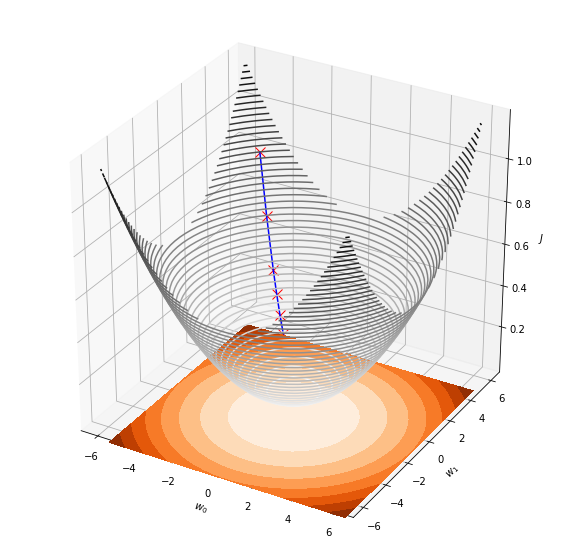

In [7]:
from mpl_toolkits import mplot3d
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.figure(figsize=(10, 10))
ax = plt.axes(projection='3d')

# indx = np.sort(np.random.randint(30,size=10))
# indy = np.sort(np.random.randint(30,size=10))

indx = [27, 25, 23,22, 21, 20]
indy = [ 3, 5 ,  7, 8, 9, 10]

xline = X[indx,indy]
yline = Y[indx,indy]
zline = Z[indx,indy]

# strtx = np.random.randint(30)
# strty = np.random.randint(30)
# indx  = 
# indy  = np.sort(np.random.randint(30,size=10))

# xline = 2*X[indx,indy]
# yline = 2*Y[indx,indy]
# zline = Z[indx,indy]
# #zline = 2*xline  # take the gradient of Z
# #+ 2*yline
colors = cm.rainbow(np.linspace(0, 1, len(xline)))

ax.set_xlabel('$w_0$')
ax.set_ylabel('$w_1$')
ax.set_zlabel('$J$')

#levels = [0.0, 0.1, 0.2, 0.4, 0.8, 0.12, 0.14]
ax.plot(xline, yline, zline,'xr', markersize=10 )
ax.plot(xline, yline, zline,'-b', markersize=30 )
ax.contour3D(X, Y, Z, 50, cmap='binary')

ax.contourf(X, Y, Z, cmap=cm.Oranges ,offset= -0.1)

#ax.plot_surface(X, Y, Z, rstride=1, cstride=1,  edgecolor='none')
#ax.plot_wireframe(X, Y, Z, color='lightgray')
plt.savefig('figures/pointsCostFunciton.png')

